---------------------------
Network Intrusion Detection
---------------------------
Null values does not not exists
The number of rows and columns are (125973, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_l

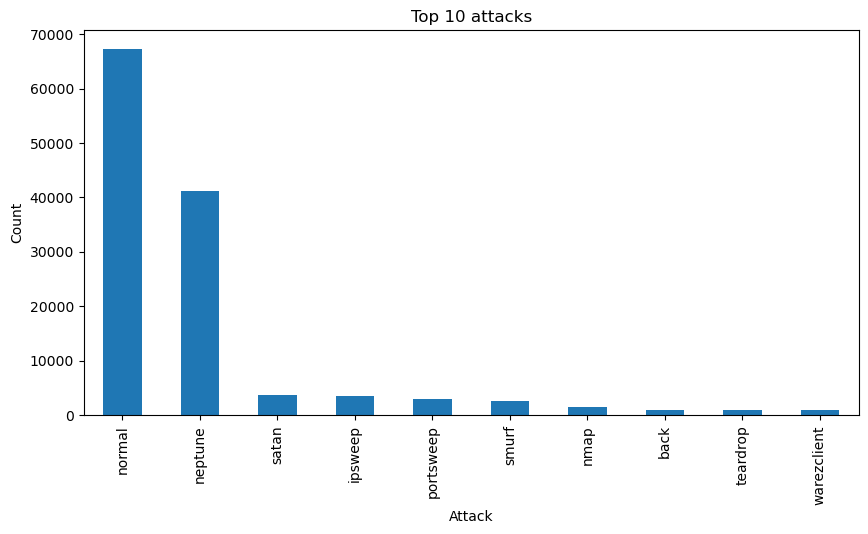

The categorical columns are Index(['protocol_type', 'service', 'flag', 'label'], dtype='object')
The number of rows and columns of input feature are (125973, 10)
The number of rows and columns of input feature are (125973,)
The accuracy is 0.9935
The f1 score is 0.9931
The precision is 0.9938
The recall is 0.9935
The classification report is as follows:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       185
           1       1.00      0.33      0.50         9
           3       1.00      0.82      0.90        11
           4       0.50      1.00      0.67         1
           5       0.88      0.99      0.93       733
           6       0.50      0.67      0.57         3
           9       1.00      1.00      1.00      8228
          10       0.99      0.70      0.82       313
          11       1.00      1.00      1.00     13422
          12       0.00      0.00      0.00         1
          13       1.00      1.00      1.00      

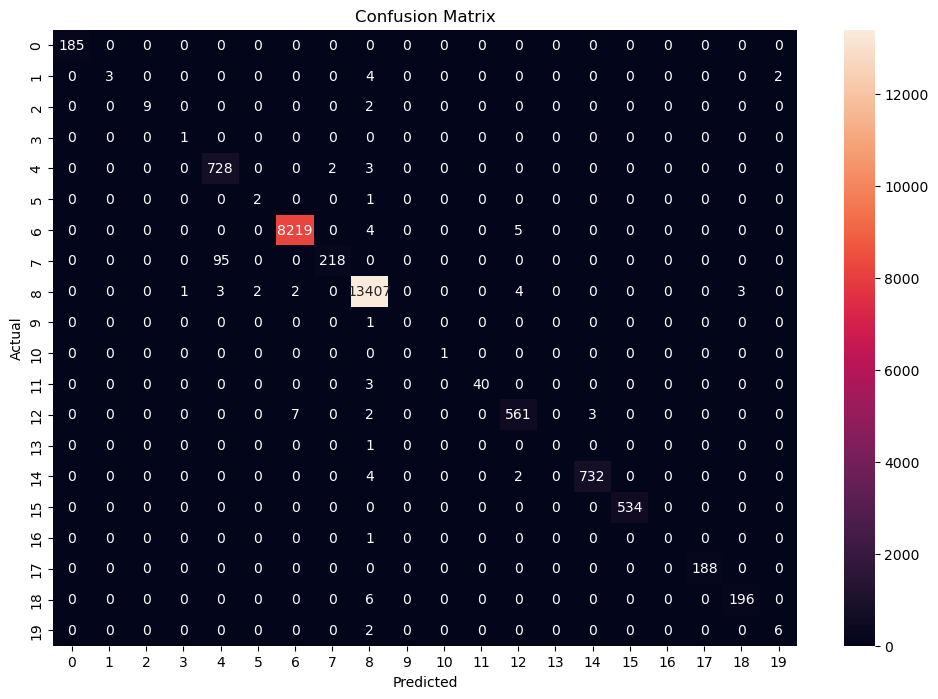

          Feature  Importance
3       src_bytes    0.232784
8   same_srv_rate    0.165299
2            flag    0.135889
7     serror_rate    0.124520
5           count    0.080783
4       dst_bytes    0.080545
0   protocol_type    0.049075
9  dst_host_count    0.047311
1         service    0.045604
6       srv_count    0.038189


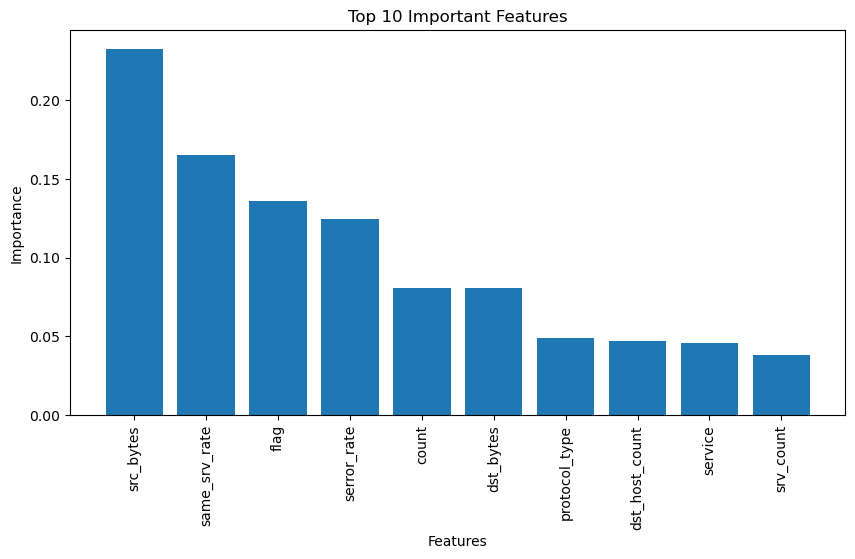

In [10]:
### 1.IMPPORTING NECESSARY LIBRARIES ###

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("---------------------------")
print("Network Intrusion Detection")
print("---------------------------")

### 2.The dataset does not contain column headers, so we manually name with what each represent ###

columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes',
'land','wrong_fragment','urgent','hot','num_failed_logins',
'logged_in','num_compromised','root_shell','su_attempted',
'num_root','num_file_creations','num_shells','num_access_files',
'num_outbound_cmds','is_host_login','is_guest_login','count',
'srv_count','serror_rate','srv_serror_rate','rerror_rate',
'srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate',
'label','difficulty'
]

### 3.Load the dataset into pandas dataframe ###

dataset = pd.read_csv("../data/KDDTrain+.txt",names=columns)

### 4.Checking for null values ###

if dataset.isnull().sum().sum() == 0 :
    print("Null values does not not exists")
else :
    print("Null values exists")

### 5.Check for structure of the dataset ###


print(f"The number of rows and columns are {dataset.shape}")
print(f"The dataset is {dataset.info()}")

### 6.List of top 20 frequent attack types ###

attack = dataset["label"].value_counts().head(20)
print(attack)

### 7.List of  unique attack types ###

unique = dataset["label"].unique()
print(f"The unique attacks are {unique} and there are {dataset["label"].nunique()} of them")

### 8.Visualization for top 10 attacks ###

top = dataset["label"].value_counts().head(10)
plt.figure(figsize=(10,5))
top.plot(kind='bar')
plt.title("Top 10 attacks")
plt.xlabel("Attack")
plt.ylabel("Count")
plt.show()

### 9.Finding categorical columns for encoding ###

categorical = dataset.select_dtypes(include ='object').columns
print(f"The categorical columns are {categorical}")

### 10. Splitting input(x) and output features(Y) ###

selected_features = [
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "count",
    "srv_count",
    "serror_rate",
    "same_srv_rate",
    "dst_host_count"
]
x = dataset[selected_features].copy()
Y = dataset["label"]

print(f"The number of rows and columns of input feature are {x.shape}")
print(f"The number of rows and columns of input feature are {Y.shape}")

### 11. Encoding catecogircal columns (x) using Label Encoder ###

from sklearn.preprocessing import LabelEncoder

protocol_encoder = LabelEncoder()
service_encoder = LabelEncoder()
flag_encoder = LabelEncoder()
label_encoder = LabelEncoder()

x['protocol_type'] = protocol_encoder.fit_transform(x['protocol_type'])
x['service'] = service_encoder.fit_transform(x['service'])
x['flag'] = flag_encoder.fit_transform(x['flag'])

Y = label_encoder.fit_transform(Y)

### Splitting training and testing subsets (80:20) ###

from sklearn.model_selection import train_test_split
x_train,x_test,Y_train,Y_test = train_test_split(x,Y,test_size =0.2,random_state =42)


### Training the model (Random Forest) ###

from sklearn.ensemble import  RandomForestClassifier
random = RandomForestClassifier(n_estimators =100,random_state=42)
random.fit(x_train,Y_train)

Y_pred = random.predict(x_test)

### Evaluation of the model  ###

from sklearn.metrics import accuracy_score, f1_score,  precision_score, classification_report, recall_score
print(f"The accuracy is {accuracy_score(Y_test,Y_pred):.4f}")
print(f"The f1 score is {f1_score(Y_test,Y_pred,average  = "weighted"):.4f}")
print(f"The precision is {precision_score(Y_test,Y_pred,average = "weighted",zero_division =0):.4f}")
print(f"The recall is {recall_score(Y_test,Y_pred, average='weighted',zero_division=0):.4f}")
print("The classification report is as follows:")
print(classification_report(Y_test,Y_pred,zero_division =0))



### Plotting confusion matrix ###

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test,Y_pred)
plt.figure(figsize=(12,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Feature importance ###

importance = random.feature_importances_
feature_importance = pd.DataFrame(
    {
        "Feature":x.columns,
        "Importance":importance
    }
)
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
print(feature_importance.head(10))

### Plotting faeture importance ###

plt.figure(figsize=(10,5))
plt.bar(
    feature_importance["Feature"].head(10),
    feature_importance["Importance"].head(10)
)
plt.xticks(rotation=90)
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()





In [11]:
import joblib

joblib.dump(random, "../models/intrusion_detection_model.pkl")

joblib.dump(protocol_encoder,
            "../models/protocol_encoder.pkl")

joblib.dump(service_encoder,
            "../models/service_encoder.pkl")

joblib.dump(flag_encoder,
            "../models/flag_encoder.pkl")

joblib.dump(label_encoder,
            "../models/label_encoder.pkl")

print("All files saved successfully")

All files saved successfully


In [12]:
joblib.dump(
    protocol_encoder,
    "../models/protocol_encoder.pkl"
)

joblib.dump(
    service_encoder,
    "../models/service_encoder.pkl"
)

joblib.dump(
    flag_encoder,
    "../models/flag_encoder.pkl"
)

joblib.dump(
    label_encoder,
    "../models/label_encoder.pkl"
)

print("All encoders saved successfully")

All encoders saved successfully


In [2]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

encoder.fit(dataset["label"])

for i, label in enumerate(encoder.classes_):
    print(i, "->", label)

0 -> back
1 -> buffer_overflow
2 -> ftp_write
3 -> guess_passwd
4 -> imap
5 -> ipsweep
6 -> land
7 -> loadmodule
8 -> multihop
9 -> neptune
10 -> nmap
11 -> normal
12 -> perl
13 -> phf
14 -> pod
15 -> portsweep
16 -> rootkit
17 -> satan
18 -> smurf
19 -> spy
20 -> teardrop
21 -> warezclient
22 -> warezmaster


In [7]:
print("Protocol Types:")
print(protocol_encoder.classes_)

print("\nFlags:")
print(flag_encoder.classes_)

print("\nFirst 30 Services:")
print(service_encoder.classes_[:30])

Protocol Types:
['icmp' 'tcp' 'udp']

Flags:
['OTH' 'REJ' 'RSTO' 'RSTOS0' 'RSTR' 'S0' 'S1' 'S2' 'S3' 'SF' 'SH']

First 30 Services:
['IRC' 'X11' 'Z39_50' 'aol' 'auth' 'bgp' 'courier' 'csnet_ns' 'ctf'
 'daytime' 'discard' 'domain' 'domain_u' 'echo' 'eco_i' 'ecr_i' 'efs'
 'exec' 'finger' 'ftp' 'ftp_data' 'gopher' 'harvest' 'hostnames' 'http'
 'http_2784' 'http_443' 'http_8001' 'imap4' 'iso_tsap']


In [8]:
selected_features = [
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "count",
    "srv_count",
    "serror_rate",
    "same_srv_rate",
    "dst_host_count"
]

x = dataset[selected_features]

print(x.head())
print(x.shape)

  protocol_type   service flag  src_bytes  dst_bytes  count  srv_count  \
0           tcp  ftp_data   SF        491          0      2          2   
1           udp     other   SF        146          0     13          1   
2           tcp   private   S0          0          0    123          6   
3           tcp      http   SF        232       8153      5          5   
4           tcp      http   SF        199        420     30         32   

   serror_rate  same_srv_rate  dst_host_count  
0          0.0           1.00             150  
1          0.0           0.08             255  
2          1.0           0.05             255  
3          0.2           1.00              30  
4          0.0           1.00             255  
(125973, 10)


In [13]:
print(x.columns.tolist())

['protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'same_srv_rate', 'dst_host_count']


In [14]:
print(protocol_encoder.classes_)
print(flag_encoder.classes_)
print(service_encoder.classes_)


['icmp' 'tcp' 'udp']
['OTH' 'REJ' 'RSTO' 'RSTOS0' 'RSTR' 'S0' 'S1' 'S2' 'S3' 'SF' 'SH']
['IRC' 'X11' 'Z39_50' 'aol' 'auth' 'bgp' 'courier' 'csnet_ns' 'ctf'
 'daytime' 'discard' 'domain' 'domain_u' 'echo' 'eco_i' 'ecr_i' 'efs'
 'exec' 'finger' 'ftp' 'ftp_data' 'gopher' 'harvest' 'hostnames' 'http'
 'http_2784' 'http_443' 'http_8001' 'imap4' 'iso_tsap' 'klogin' 'kshell'
 'ldap' 'link' 'login' 'mtp' 'name' 'netbios_dgm' 'netbios_ns'
 'netbios_ssn' 'netstat' 'nnsp' 'nntp' 'ntp_u' 'other' 'pm_dump' 'pop_2'
 'pop_3' 'printer' 'private' 'red_i' 'remote_job' 'rje' 'shell' 'smtp'
 'sql_net' 'ssh' 'sunrpc' 'supdup' 'systat' 'telnet' 'tftp_u' 'tim_i'
 'time' 'urh_i' 'urp_i' 'uucp' 'uucp_path' 'vmnet' 'whois']
